# Module Overview Generator

This notebook generates a comprehensive overview of LemonTree modules with expression prioritization and pathway enrichment.

**Output Files:**
- `Module_Overview_Complete.csv` - Comprehensive module data table
- `Module_prioritization_expression_*.csv` - Expression prioritization results
- `Module_Expression_Heatmap.png` - Heatmap visualization

**Note:** Run the visualization notebook (`Module_Network_Visualization.ipynb`) after this to create network visualizations.

In [29]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import warnings
from scipy.stats import mannwhitneyu, kruskal
from scipy.cluster.hierarchy import linkage, fcluster
import json

In [30]:
# Define Input File Paths and Configuration
# You may need to adjust these paths based on your directory structure

# Working directory - change this to match your setup
base_dir = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/'
os.chdir(base_dir)

# Configuration parameters
percentile = 2  # Percentile cutoff used in regulator selection (top 2%)
modules_name = '46'

# Expression prioritization configuration
prioritize_by_expression = True  # Use expression-based prioritization

# Core data files
clusterfile = './ModuleViewer_files/clusters_list.txt'
TF_regulator_file = './ModuleViewer_files/Lovering.percentile' + str(percentile) + '_list.txt'
metabolite_regulator_file = './ModuleViewer_files/Metabolite.percentile' + str(percentile) + '_list.txt'
lipid_regulator_file = './ModuleViewer_files/Lipid.percentile' + str(percentile) + '_list.txt'

# Module coherence scores (generated by LemonTree_to_network.ipynb)
coherence_scores_file = 'Module_coherence_scores.txt'

# Expression and metadata files (for prioritization)
expression_complete = './Preprocessing/LemonPreprocessed_complete.txt'
DESeq_groups = './Preprocessing/DESeq_groups.txt'

# Pathway enrichment files
enrichment_up_file = './Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_up_per_module.csv'
enrichment_down_file = './Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_down_per_module.csv'

print("Configuration set successfully!")
print(f"Base directory: {base_dir}")
print(f"Expression prioritization: {prioritize_by_expression}")
print(f"Percentile cutoff: top {percentile}%")
print(f"Module set: {modules_name}")

Configuration set successfully!
Base directory: /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/
Expression prioritization: True
Percentile cutoff: top 2%
Module set: 46


In [31]:
# Get list of modules_to_process
network = pd.read_csv(f'./Networks/LemonNetwork_percentile{percentile}_{modules_name}modules.txt', sep='\t', index_col=False)
modules_to_process = network['Lemon_module'].unique().tolist()
print(modules_to_process)
print(len(modules_to_process))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 20, 21, 23, 24, 26, 29, 30, 33, 36, 37, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 51, 53, 54, 56, 57, 60, 61, 62]
46


In [32]:
# Function to Parse Regulator and Gene Lists into Dictionaries

def get_regulators(regfile):
    """
    Parse regulator/gene list files into dictionaries.
    
    Parameters:
    regfile (str): Path to the regulator/gene list file
    
    Returns:
    dict: Dictionary mapping module IDs to lists of regulators/genes
    """
    regs = {}
    try:
        with open(regfile) as f:
            for line in f:
                if line.strip():  # Skip empty lines
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        module = parts[0].strip()
                        regulators = parts[1].rstrip().split('|')
                        regs[module] = regulators
    except FileNotFoundError:
        print(f"Warning: File {regfile} not found. Creating empty dictionary.")
        regs = {}
    except Exception as e:
        print(f"Error reading {regfile}: {e}")
        regs = {}
    
    return regs

print("Function get_regulators() defined successfully!")

Function get_regulators() defined successfully!


In [33]:
# Load Module-Regulator and Module-Gene Mappings

# Load regulator assignments for each module
module2TFs = get_regulators(TF_regulator_file)
module2mets = get_regulators(metabolite_regulator_file)
module2lipids = get_regulators(lipid_regulator_file)
module2genes = get_regulators(clusterfile)

print("Module-Regulator Mappings Loaded:")
print(f"- TF regulators: {len(module2TFs)} modules")
print(f"- Metabolite regulators: {len(module2mets)} modules")
print(f"- Lipid regulators: {len(module2lipids)} modules")
print(f"- Gene clusters: {len(module2genes)} modules")

# Display sample data
if module2genes:
    sample_module = list(module2genes.keys())[0]
    print(f"\nSample module {sample_module}:")
    print(f"- Genes: {module2genes[sample_module][:5]}..." if len(module2genes[sample_module]) > 5 else f"- Genes: {module2genes[sample_module]}")
    if sample_module in module2mets:
        print(f"- Metabolites: {module2mets[sample_module]}")
    if sample_module in module2TFs:
        print(f"- TFs: {module2TFs[sample_module]}")

Module-Regulator Mappings Loaded:
- TF regulators: 60 modules
- Metabolite regulators: 55 modules
- Lipid regulators: 60 modules
- Gene clusters: 63 modules

Sample module 0:
- Genes: ['VSTM2L', 'GABRA5', 'SYT4', 'CREG2', 'SYNGR3']...
- Metabolites: ['creatinine', 'L_lysine']
- TFs: ['EMX1', 'SOHLH1', 'MYT1L']


In [34]:
from statsmodels.stats.multitest import multipletests
# Enhanced Module Prioritization with Automatic Group Detection

def prioritize_modules_expression(condition1='UC', condition2='nonIBD', modules_dict=None):
    """
    Prioritize modules based on differential expression between conditions
    Automatically detects number of groups and chooses appropriate statistical test:
    - 2 groups: Mann-Whitney U test
    - 3+ groups: Kruskal-Wallis H-test
    """
    
    try:
        # Load sample mapping from metadata
        print("Loading sample annotations...")
        annotations = pd.read_csv(DESeq_groups, sep='\t')
        
        if 'Sample_ID' not in annotations.columns:
            annotations['Sample_ID'] = annotations.index
        print(annotations.head())
        
        sample_mapping = dict(zip(annotations['Sample_ID'], annotations['multiomic']))
        print(f"{len(sample_mapping)} samples included in the analysis.")
        
        unique_groups = annotations['multiomic'].unique()
        num_groups = len(unique_groups)
        
        print(f"Detected {num_groups} multiomic groups: {list(unique_groups)}")
        
        if modules_dict is None:
            modules_dict = module2genes.copy()
        
        for module in modules_dict:
            if isinstance(modules_dict[module], str):
                modules_dict[module] = modules_dict[module].split('|')
        
        module_p_values = {}
        
        print("Loading expression data...")
        expression_data = pd.read_csv(expression_complete, sep='\t')
        
        print(f"Processing {len(modules_dict)} modules for expression prioritization...")
        
        for module in modules_dict:
            genes = modules_dict[module]
            data_to_use = expression_data[expression_data['symbol'].isin(genes)]
            
            if len(data_to_use) == 0:
                module_p_values[module] = 1.0
                continue
            
            data_to_use = data_to_use.iloc[:, 2:len(data_to_use.columns)-1]
            means = data_to_use.mean(axis=0)
            means_df = means.to_frame()
            means_df.columns = ['expression']
            means_df.index.name = 'sample'
            means_df.reset_index(inplace=True)
            
            if num_groups == 2:
                group1_samples = [key for key, value in sample_mapping.items() if value == condition1]
                group2_samples = [key for key, value in sample_mapping.items() if value == condition2]
                
                group1_expression = means_df[means_df['sample'].isin(group1_samples)]
                group2_expression = means_df[means_df['sample'].isin(group2_samples)]
                
                group1 = group1_expression['expression'].tolist()
                group2 = group2_expression['expression'].tolist()
                
                if len(group1) > 0 and len(group2) > 0:
                    stat, p = mannwhitneyu(group1, group2)
                    module_p_values[module] = p
                else:
                    module_p_values[module] = 1.0
                    
            elif num_groups > 2:
                group_expressions = []
                
                for group in unique_groups:
                    group_samples = [key for key, value in sample_mapping.items() if value == group]
                    group_expression = means_df[means_df['sample'].isin(group_samples)]['expression'].tolist()
                    group_expressions.append(group_expression)
                
                non_empty_groups = [group for group in group_expressions if len(group) > 0]
                
                if len(non_empty_groups) >= 2:
                    try:
                        stat, p = kruskal(*non_empty_groups)
                        module_p_values[module] = p
                    except Exception as e:
                        module_p_values[module] = 1.0
                else:
                    module_p_values[module] = 1.0
            else:
                module_p_values[module] = 1.0
        
        modules_ordered = {k: v for k, v in sorted(module_p_values.items(), key=lambda item: item[1])}
        
        p_values_list = list(modules_ordered.values())
        _, p_adjusted, _, _ = multipletests(p_values_list, method="fdr_bh")
        modules_ordered_adjusted = dict(zip(modules_ordered.keys(), p_adjusted))
        
        prioritization_df = pd.DataFrame(list(modules_ordered.items()), columns=["Module", "p_value"])
        prioritization_df["p_adjusted"] = list(modules_ordered_adjusted.values())
        
        sig_count = sum(1 for p in modules_ordered.values() if p < 0.05)
        
        if num_groups == 2:
            test_type = "Mann-Whitney U test"
            filename = 'Module_prioritization_expression_two_group.csv'
        else:
            test_type = "Kruskal-Wallis H-test"
            filename = 'Module_prioritization_expression_multi_group.csv'
        
        print(f"\nModule prioritization completed:")
        print(f"- Total modules: {len(modules_ordered)}")
        print(f"- Significant modules (p < 0.05): {sig_count}")
        print(f"- Statistical test: {test_type}")
        
        prioritization_df.to_csv(filename, index=False)
        print(f"Results saved to: {filename}")
        
        return modules_ordered, prioritization_df, test_type
        
    except Exception as e:
        print(f"Error in expression prioritization: {e}")
        return {str(k): 1.0 for k in modules_dict.keys() if modules_dict}, pd.DataFrame(), "None"

print("Enhanced expression prioritization function defined!")

Enhanced expression prioritization function defined!


In [35]:
# Execute Enhanced Module Prioritization

prioritize_by_expression = True
condition1 = ''
condition2 = ''

if prioritize_by_expression:
    print("Running enhanced module prioritization...")
    print("="*70)
    
    expression_order, prioritization_df, test_type = prioritize_modules_expression(
        condition1=condition1, 
        condition2=condition2, 
        modules_dict=module2genes
    )
    
    if not prioritization_df.empty:
        module_pvalues = dict(zip(prioritization_df['Module'], prioritization_df['p_value']))
        module_pvalues_adjusted = dict(zip(prioritization_df["Module"], prioritization_df["p_adjusted"]))
        module_ranks = {module: idx + 1 for idx, module in enumerate(prioritization_df['Module'])}
        
        print("\nTop 10 Most Significant Modules:")
        print(prioritization_df.head(10))
    else:
        module_pvalues = {}
        module_ranks = {}
else:
    module_pvalues = {}
    module_ranks = {}

Running enhanced module prioritization...
Loading sample annotations...
           cause_of_death  gender  age_at_diagnosis progression_or_recurrence  \
C3L-00365         Unknown  female                59              not reported   
C3L-00674  Cancer Related    male                46                       yes   
C3L-00677  Cancer Related  female                70                        no   
C3L-01043  Cancer Related    male                59              not reported   
C3L-01045       Infection  female                74              not reported   

          site_of_resection_or_biopsy diagnosis sample_type multiomic  \
C3L-00365               Parietal lobe       GBM       tumor      nmf3   
C3L-00674                Frontal lobe       GBM       tumor      nmf1   
C3L-00677                Frontal lobe       GBM       tumor      nmf1   
C3L-01043               Parietal lobe       GBM       tumor      nmf2   
C3L-01045               Temporal lobe       GBM       tumor      nmf3   

  

In [36]:
# Load Pathway Enrichment Data
module_enrichment_up = pd.read_csv(enrichment_up_file, sep=',')
module_enrichment_up

,Module,Database,Term,p.adjust
0,0,BP,Chemical Synaptic Transmission (GO:0007268),4.870509e-08
1,0,BP,Synaptic Vesicle Exocytosis (GO:0016079),1.525290e-07
2,0,BP,Anterograde Trans-Synaptic Signaling (GO:0098916),1.528626e-06
3,0,BP,Synaptic Vesicle Cycle (GO:0099504),4.656435e-06
4,0,BP,Regulation of Calcium Ion-Dependent Exocytosis...,6.325166e-04
...,...,...,...,...
1057,62,KEGG,Taurine and hypotaurine metabolism,4.685508e-02
1058,62,KEGG,Butanoate metabolism,4.685508e-02
1059,62,KEGG,beta-Alanine metabolism,4.685508e-02
1060,62,KEGG,"Alanine, aspartate and glutamate metabolism",4.685508e-02


In [37]:
# Process Pathway Enrichment Data
try:
    module_enrichment_up = pd.read_csv(enrichment_up_file, sep=',')
    module_enrichment_up['direction'] = 'Up'
    module_enrichment = module_enrichment_up
    module_enrichment['Term_direction'] = module_enrichment['Term'] + '_' + module_enrichment['direction']
    
    print("Pathway Enrichment Data Loaded:")
    print(f"- Up-regulated pathways: {len(module_enrichment_up)} entries")
    print(f"- Unique modules: {module_enrichment['Module'].nunique()}")
    print(f"- Databases: {list(module_enrichment['Database'].unique())}")
    
    enrichment_available = True
    
except Exception as e:
    print(f"Warning: Could not load enrichment data: {e}")
    module_enrichment = pd.DataFrame()
    enrichment_available = False

Pathway Enrichment Data Loaded:
- Up-regulated pathways: 1062 entries
- Unique modules: 45
- Databases: ['BP', 'MF', 'CC', 'KEGG', 'Reactome']


In [38]:
# Parse Pathway Enrichment Data into Dictionaries

if enrichment_available and not module_enrichment.empty:
    module2BP = {}
    module2MF = {}
    module2CC = {}
    module2KEGG = {}
    module2Reactome = {}
    
    print("Processing pathway enrichment data...")
    
    for module in module_enrichment['Module'].unique():
        data = module_enrichment[module_enrichment['Module'] == module]
        
        BP = data[data['Database'] == 'BP'].sort_values(by='p.adjust', ascending=True)
        MF = data[data['Database'] == 'MF'].sort_values(by='p.adjust', ascending=True)
        CC = data[data['Database'] == 'CC'].sort_values(by='p.adjust', ascending=True)
        KEGG = data[data['Database'] == 'KEGG'].sort_values(by='p.adjust', ascending=True)
        Reactome = data[data['Database'] == 'Reactome'].sort_values(by='p.adjust', ascending=True)
        
        module2BP[module] = BP[:3]['Term_direction'].tolist()
        module2MF[module] = MF[:3]['Term_direction'].tolist()
        module2CC[module] = CC[:3]['Term_direction'].tolist()
        module2KEGG[module] = KEGG[:3]['Term_direction'].tolist()
        module2Reactome[module] = Reactome[:3]['Term_direction'].tolist()
    
    print(f"Pathway Dictionaries Created:")
    print(f"- BP: {len(module2BP)} modules")
    print(f"- MF: {len(module2MF)} modules")
    print(f"- CC: {len(module2CC)} modules")
    print(f"- KEGG: {len(module2KEGG)} modules")
    print(f"- Reactome: {len(module2Reactome)} modules")
        
else:
    module2BP = {}
    module2MF = {}
    module2CC = {}
    module2KEGG = {}
    module2Reactome = {}

Processing pathway enrichment data...
Pathway Dictionaries Created:
- BP: 45 modules
- MF: 45 modules
- CC: 45 modules
- KEGG: 45 modules
- Reactome: 45 modules


In [39]:
# Load PPI Enrichment Data
# Initialize variables in case this cell hasn't been run yet
if 'ppi_enrichment_available' not in globals():
    module2ppi = {}
    ppi_enrichment_available = False

try:
    ppi_enrichment_file = './ModuleViewer_files/PPI_enrichment_results.csv'
    ppi_enrichment_df = pd.read_csv(ppi_enrichment_file)
    print(f"✓ Loaded PPI enrichment data: {len(ppi_enrichment_df)} modules")
    
    # Create dictionary for easy lookup
    module2ppi = {}
    for _, row in ppi_enrichment_df.iterrows():
        # Convert to int first to remove .0, then to string for consistent lookup
        module_id = str(int(row['Module']))
        module2ppi[module_id] = {
            'PPI_FDR': row['FDR'],
            'PPI_fold_enrichment': row['Fold_enrichment']
        }
    
    print(f"\nPPI Enrichment Summary:")
    n_significant = (ppi_enrichment_df['FDR'] < 0.05).sum()
    print(f"- Modules significantly enriched for PPIs (FDR < 0.05): {n_significant}")
    print(f"- Mean fold enrichment: {ppi_enrichment_df['Fold_enrichment'].mean():.2f}")
    
    # Debug: Check module ID overlap
    ppi_module_ids = set(str(m) for m in ppi_enrichment_df['Module'])
    overview_module_ids = set(str(m) for m in modules_to_process)
    matching_modules = ppi_module_ids.intersection(overview_module_ids)
    print(f"- Modules in PPI file: {len(ppi_module_ids)}")
    print(f"- Modules in overview: {len(overview_module_ids)}")
    print(f"- Matching modules: {len(matching_modules)}")
    if len(matching_modules) < len(overview_module_ids):
        missing = overview_module_ids - ppi_module_ids
        print(f"- Modules in overview but not in PPI file: {sorted(missing)}")
    
    ppi_enrichment_available = True
    
except FileNotFoundError as e:
    print(f"Warning: PPI enrichment file not found: {e}")
    print("Continuing without PPI enrichment data...")
    module2ppi = {}
    ppi_enrichment_available = False
    
except Exception as e:
    print(f"Error loading PPI enrichment data: {e}")
    print("Continuing without PPI enrichment data...")
    module2ppi = {}
    ppi_enrichment_available = False

✓ Loaded PPI enrichment data: 63 modules

PPI Enrichment Summary:
- Modules significantly enriched for PPIs (FDR < 0.05): 30
- Mean fold enrichment: 5.29
- Modules in PPI file: 63
- Modules in overview: 46
- Matching modules: 46


In [40]:
# Create comprehensive module overview DataFrame

# Ensure PPI variables are initialized
if 'ppi_enrichment_available' not in globals():
    print("⚠ Warning: PPI enrichment cell hasn't been run. Run the PPI loading cell first for complete data.")
    module2ppi = {}
    ppi_enrichment_available = False

module_data = []

if prioritize_by_expression:
    module_pvalues = expression_order
    sorted_modules = sorted(expression_order.items(), key=lambda x: x[1])
    module_ranks = {module: rank + 1 for rank, (module, _) in enumerate(sorted_modules)}

for module in modules_to_process:
    TFs = module2TFs.get(str(module), 'NA')
    mets = module2mets.get(str(module), 'NA')
    lips = module2lipids.get(str(module), 'NA')
    genes = module2genes.get(str(module), 'NA')
    
    if isinstance(TFs, list):
        TFs = '|'.join(TFs) if TFs != [''] else 'NA'
    if isinstance(mets, list):
        mets = '|'.join(mets) if mets != [''] else 'NA'
    if isinstance(lips, list):
        lips = '|'.join(lips) if lips != [''] else 'NA'
    if isinstance(genes, list):
        genes = '|'.join(genes) if genes != [''] else 'NA'
    
    expression_p_value = module_pvalues.get(str(module), 'NA')
    expression_p_adjusted = module_pvalues_adjusted.get(str(module), "NA")    
    expression_rank = module_ranks.get(str(module), 'NA')
    expression_significant = 'Yes' if (expression_p_value != 'NA' and expression_p_value < 0.05) else 'No'
    if expression_p_value == 'NA':
        expression_significant = 'NA'
    
    try:
        module_int = int(module)
        BP = module2BP.get(module_int, module2BP.get(str(module), 'NA'))
        MF = module2MF.get(module_int, module2MF.get(str(module), 'NA'))
        CC = module2CC.get(module_int, module2CC.get(str(module), 'NA'))
        KEGG = module2KEGG.get(module_int, module2KEGG.get(str(module), 'NA'))
        Reactome = module2Reactome.get(module_int, module2Reactome.get(str(module), 'NA'))
    except ValueError:
        BP = module2BP.get(str(module), 'NA')
        MF = module2MF.get(str(module), 'NA')
        CC = module2CC.get(str(module), 'NA')
        KEGG = module2KEGG.get(str(module), 'NA')
        Reactome = module2Reactome.get(str(module), 'NA')
    
    BP = str(BP) if BP != 'NA' else 'NA'
    MF = str(MF) if MF != 'NA' else 'NA'
    CC = str(CC) if CC != 'NA' else 'NA'
    KEGG = str(KEGG) if KEGG != 'NA' else 'NA'
    Reactome = str(Reactome) if Reactome != 'NA' else 'NA'
    
    # Get PPI enrichment data
    ppi_data = module2ppi.get(str(module), {})
    ppi_fdr = ppi_data.get('PPI_FDR', 'NA')
    ppi_fold_enrichment = ppi_data.get('PPI_fold_enrichment', 'NA')
    
    # Debug: Print for first module to see what's happening
    if module == modules_to_process[0]:
        print(f"\n🔍 Debug Info for Module {module}:")
        print(f"  - Module ID as string: '{str(module)}'")
        print(f"  - Module ID type: {type(module)}")
        print(f"  - Is in module2ppi dict? {str(module) in module2ppi}")
        print(f"  - Sample PPI dict keys: {list(module2ppi.keys())[:5]}")
        print(f"  - PPI FDR value: {ppi_fdr}")
        print(f"  - PPI fold enrichment: {ppi_fold_enrichment}\n")
    
    module_entry = {
        'Module': module,
        'TF_regulators': TFs,
        'Metabolite_regulators': mets,
        'Lipid_regulators': lips,
        'Module_genes': genes,
        'Top_3_pathways_bio_process': BP,
        'Top_3_pathways_molecular_function': MF,
        'Top_3_pathways_cellular_component': CC,
        'Top_3_pathways_KEGG': KEGG,
        'Top_3_pathways_Reactome': Reactome
    }
    
    if prioritize_by_expression:
        module_entry.update({
            'Expression_p_value': expression_p_value,
            'Expression_p_adjusted': expression_p_adjusted,
            'Expression_rank': expression_rank,
            'Expression_test_type': test_type,
            'Expression_significant': expression_significant
        })
    
    # Add PPI enrichment data if available
    if ppi_enrichment_available:
        module_entry.update({
            'PPI_FDR': ppi_fdr,
            'PPI_fold_enrichment': ppi_fold_enrichment
        })
    
    module_data.append(module_entry)

base_columns = [
    'Module', 'TF_regulators', 'Metabolite_regulators', 'Lipid_regulators',
    'Module_genes', 'Top_3_pathways_bio_process', 'Top_3_pathways_molecular_function', 
    'Top_3_pathways_cellular_component', 'Top_3_pathways_KEGG', 'Top_3_pathways_Reactome'
]

if prioritize_by_expression:
    expression_columns = ['Expression_p_adjusted', 'Expression_rank', 'Expression_test_type', 'Expression_significant']
    columns = base_columns[:4] + expression_columns + base_columns[4:]
else:
    columns = base_columns

# Add PPI enrichment columns if available
if ppi_enrichment_available:
    ppi_columns = ['PPI_FDR', 'PPI_fold_enrichment']
    # Insert PPI columns after expression columns (if present) or after lipid_regulators
    if prioritize_by_expression:
        insert_position = base_columns.index('Module_genes') + len(expression_columns)
        columns = columns[:insert_position] + ppi_columns + columns[insert_position:]
    else:
        insert_position = base_columns.index('Module_genes')
        columns = columns[:insert_position] + ppi_columns + columns[insert_position:]

module_overview = pd.DataFrame(module_data, columns=columns)

if prioritize_by_expression and 'Expression_rank' in module_overview.columns:
    module_overview = module_overview.sort_values(['Expression_rank', 'Module']).reset_index(drop=True)

print(f"Module overview created: {len(module_overview)} modules")
if prioritize_by_expression:
    sig_count = sum(module_overview['Expression_significant'] == 'Yes')
    print(f"Significant modules: {sig_count}")


🔍 Debug Info for Module 0:
  - Module ID as string: '0'
  - Module ID type: <class 'int'>
  - Is in module2ppi dict? True
  - Sample PPI dict keys: ['10', '5', '0', '33', '1']
  - PPI FDR value: 2.7225711916672523e-188
  - PPI fold enrichment: 9.003558076874818

Module overview created: 46 modules
Significant modules: 42


In [41]:
# Save Module Overview DataFrame

output_filename = 'Module_Overview_Complete.csv'
module_overview.to_csv(output_filename, sep='\t', index=False)

print(f"✅ Module overview saved: {output_filename}")
print(f"   Total modules: {len(module_overview)}")

# Display summary statistics
print(f"\nSummary:")
tf_count = sum(1 for x in module_overview['TF_regulators'] if x != 'NA')
met_count = sum(1 for x in module_overview['Metabolite_regulators'] if x != 'NA')
lip_count = sum(1 for x in module_overview['Lipid_regulators'] if x != 'NA')
bp_count = sum(1 for x in module_overview['Top_3_pathways_bio_process'] if x != 'NA')

print(f"- Modules with TF regulators: {tf_count}")
print(f"- Modules with Metabolite regulators: {met_count}")
print(f"- Modules with Lipid regulators: {lip_count}")
print(f"- Modules with BP pathways: {bp_count}")

if ppi_enrichment_available and 'PPI_FDR' in module_overview.columns:
    ppi_available = sum(1 for x in module_overview['PPI_FDR'] if x != 'NA')
    ppi_significant = sum(1 for x in module_overview['PPI_FDR'] if x != 'NA' and x < 0.05)
    print(f"- Modules with PPI enrichment data: {ppi_available}")
    print(f"- Significantly enriched modules (FDR < 0.05): {ppi_significant}")

if prioritize_by_expression and 'Expression_significant' in module_overview.columns:
    expression_significant = sum(1 for x in module_overview['Expression_significant'] if x == 'Yes')
    print(f"- Significantly different modules: {expression_significant}")

print("\n✅ Module overview ready! Run Module_Network_Visualization.ipynb for network visualizations.")

✅ Module overview saved: Module_Overview_Complete.csv
   Total modules: 46

Summary:
- Modules with TF regulators: 46
- Modules with Metabolite regulators: 45
- Modules with Lipid regulators: 46
- Modules with BP pathways: 45
- Modules with PPI enrichment data: 46
- Significantly enriched modules (FDR < 0.05): 21
- Significantly different modules: 42

✅ Module overview ready! Run Module_Network_Visualization.ipynb for network visualizations.


Loading expression data...
✅ Heatmap saved: Module_Expression_Heatmap.png


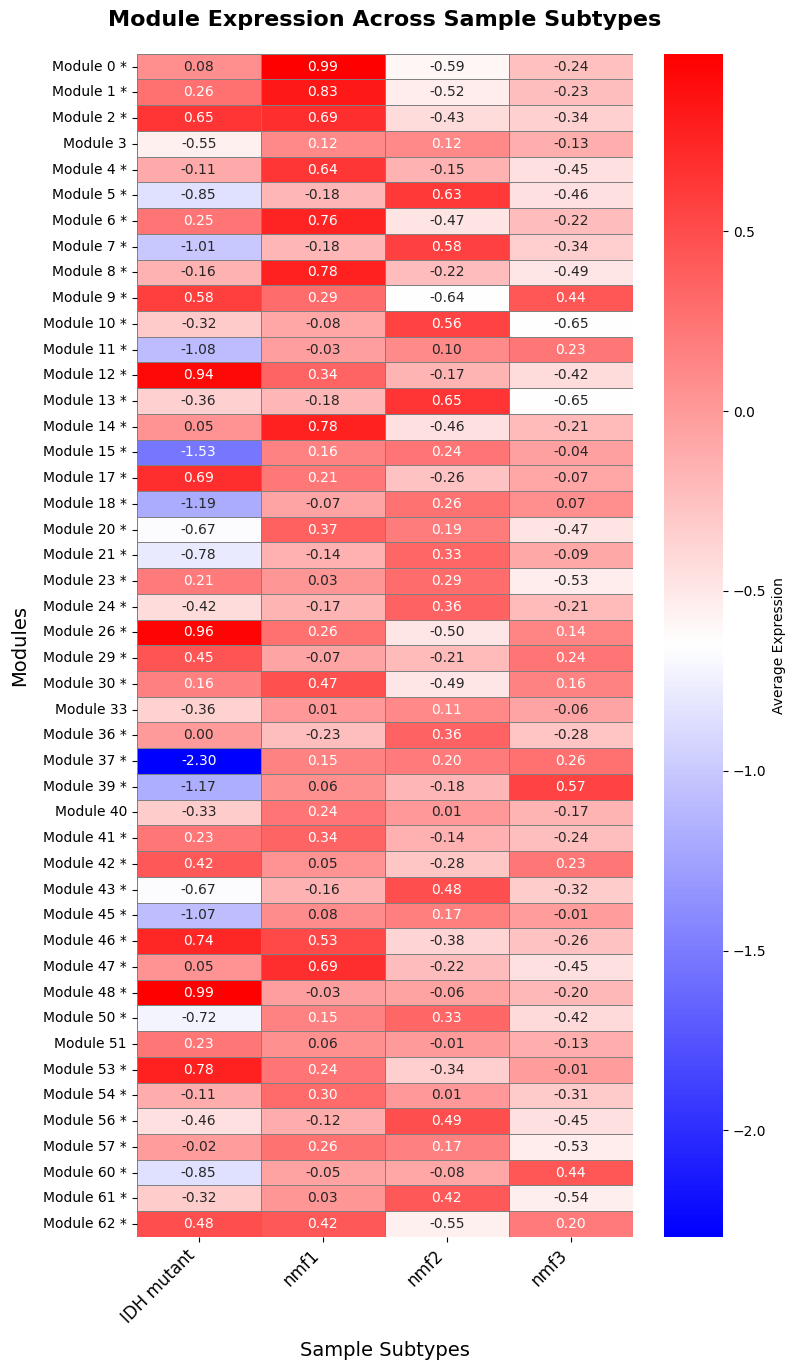

In [42]:
def module_heatmap_expression():
    """
    Create a heatmap showing average module expression across sample subtypes.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.colors import LinearSegmentedColormap

    try:
        print("Loading expression data...")
        expression_data = pd.read_csv(expression_complete, sep='\t')
        annotations = pd.read_csv(DESeq_groups, sep='\t')

        if 'Sample_ID' not in annotations.columns:
            annotations['Sample_ID'] = annotations.index
        sample_mapping = dict(zip(annotations['Sample_ID'], annotations['multiomic']))
        unique_groups = sorted(annotations['multiomic'].unique())

        heatmap_data = []

        for module in modules_to_process:
            if str(module) in module2genes:
                genes = module2genes[str(module)]
                module_expression = expression_data[expression_data['symbol'].isin(genes)]

                if len(module_expression) == 0:
                    continue

                numeric_cols = module_expression.select_dtypes(include=[np.number]).columns
                module_expression = module_expression[numeric_cols]
                sample_means = module_expression.mean(axis=0)

                group_averages = {}
                for group in unique_groups:
                    group_samples = [sample for sample, group_name in sample_mapping.items() if group_name == group]
                    group_samples_in_data = [s for s in group_samples if s in sample_means.index]

                    if group_samples_in_data:
                        group_averages[group] = sample_means[group_samples_in_data].mean()
                    else:
                        group_averages[group] = np.nan

                row_data = [group_averages[group] for group in unique_groups]
                heatmap_data.append(row_data)

        if not heatmap_data:
            print("No data available for heatmap")
            return

        heatmap_df = pd.DataFrame(heatmap_data,
                                  index=[f"Module {m}{' *' if str(m) in module_pvalues and module_pvalues[str(m)] < 0.05 else ''}"
                                         for m in modules_to_process],
                                  columns=unique_groups)
        heatmap_df = heatmap_df.dropna(how='all')

        cmap = LinearSegmentedColormap.from_list('custom_cmap', ['blue', 'white', 'red'])
        plt.figure(figsize=(8, max(8, len(heatmap_df) * 0.3)))

        ax = sns.heatmap(heatmap_df, cmap=cmap, annot=True, fmt='.2f',
                        linewidths=0.5, linecolor='gray',
                        cbar_kws={'label': 'Average Expression'})

        plt.title('Module Expression Across Sample Subtypes', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Sample Subtypes', fontsize=14, labelpad=10)
        plt.ylabel('Modules', fontsize=14, labelpad=10)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(fontsize=10)
        plt.tight_layout()
        plt.savefig('Module_Expression_Heatmap.png', dpi=300, bbox_inches='tight')

        print(f"✅ Heatmap saved: Module_Expression_Heatmap.png")
        plt.show()

    except Exception as e:
        print(f"Error creating heatmap: {e}")
        import traceback
        traceback.print_exc()

module_heatmap_expression()